In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

os.makedirs(os.path.join('..', 'models'), exist_ok=True)
os.makedirs(os.path.join('..', 'outputs', 'plots'), exist_ok=True)


In [2]:
# Load data/processed/steam_cleaned.csv
data_path = os.path.join('..', 'data', 'processed', 'steam_cleaned.csv')
print(f"Loading cleaned data from {data_path}")
df = pd.read_csv(data_path)

df = df.dropna(subset=['cleaned_review', 'helpfulness_label'])


Loading cleaned data from ..\data\processed\steam_cleaned.csv


In [3]:
# Load Sentiment LR model and TF-IDF
print("Loading Sentiment Models to engineer score...")
vectorizer = joblib.load(os.path.join('..', 'models', 'sentiment_tfidf.pkl'))
lr_model = joblib.load(os.path.join('..', 'models', 'sentiment_lr.pkl'))

# Transform reviews and get probabilities for the whole dataset
X_tfidf = vectorizer.transform(df['cleaned_review'].astype(str))
sentiment_scores = lr_model.predict_proba(X_tfidf)[:, 1]

# Add sentiment_score as feature
df['sentiment_score'] = sentiment_scores


Loading Sentiment Models to engineer score...


In [4]:
# Features X and y
features = ['review_length', 'word_count', 'playtime_hours', 'is_early_access', 'sentiment_score']
X = df[features]
y = df['helpfulness_label']

# Handle any nan in X
X = X.fillna(0)

# Split: 80/20, stratified, random_state=42
print("Splitting dataset 80/20")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


Splitting dataset 80/20


In [5]:
# Model: RandomForestClassifier
print("Training RandomForest Classifier...")
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Save
joblib.dump(rf_model, os.path.join('..', 'models', 'helpfulness_rf.pkl'))


Training RandomForest Classifier...


['..\\models\\helpfulness_rf.pkl']

In [6]:
# Evaluate
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("### Random Forest Helpfulness Metrics ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")


### Random Forest Helpfulness Metrics ###
Accuracy: 0.5586
F1-Score: 0.2871
ROC-AUC:  0.6022


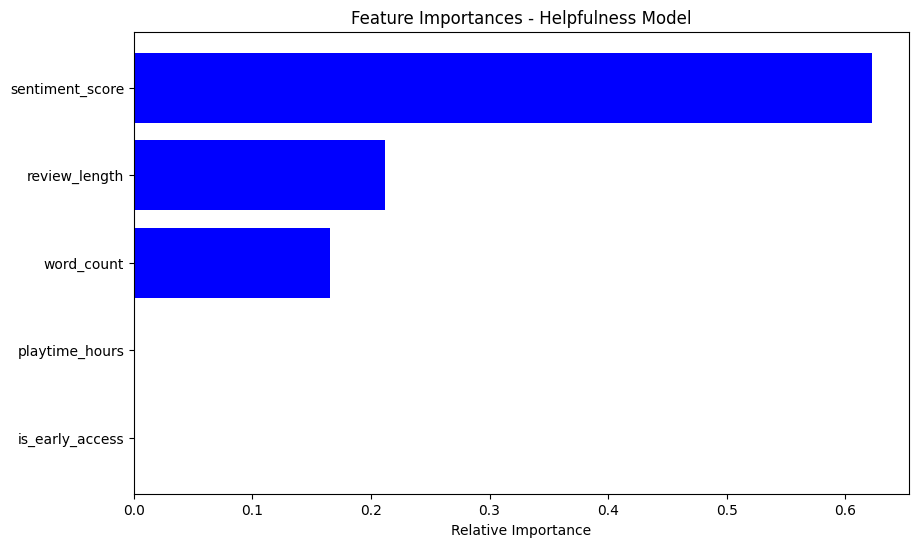

In [7]:
# Plot: Feature importance bar chart
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances - Helpfulness Model')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.savefig(os.path.join('..', 'outputs', 'plots', '11_helpfulness_feature_importance.png'))
plt.show()


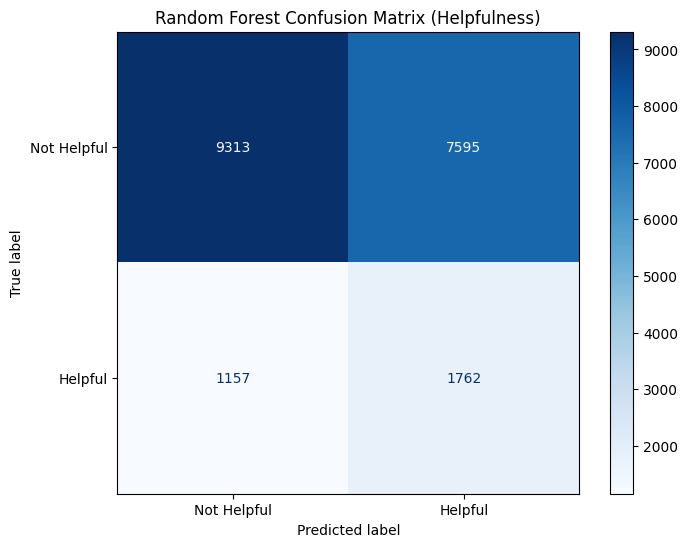

In [8]:
# Plot: Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Helpful', 'Helpful'])

plt.figure(figsize=(8, 6))
ax = plt.gca()
disp_rf.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Random Forest Confusion Matrix (Helpfulness)')
plt.savefig(os.path.join('..', 'outputs', 'plots', '12_helpfulness_confusion_matrix.png'))
plt.show()
